First 5 records:
          Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Unnamed: 16  


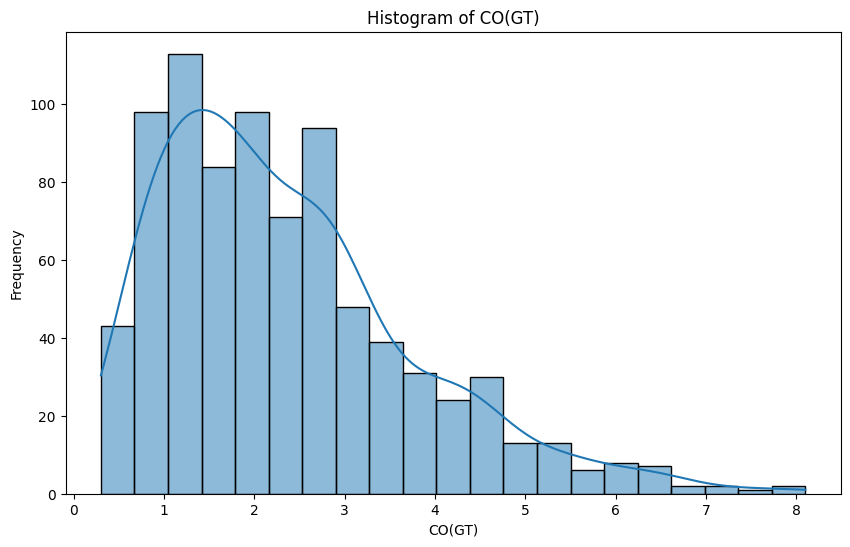

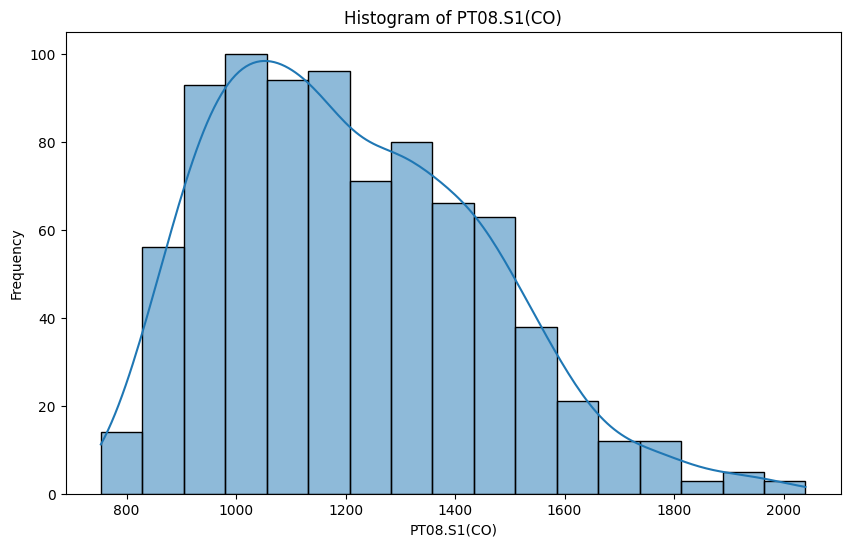

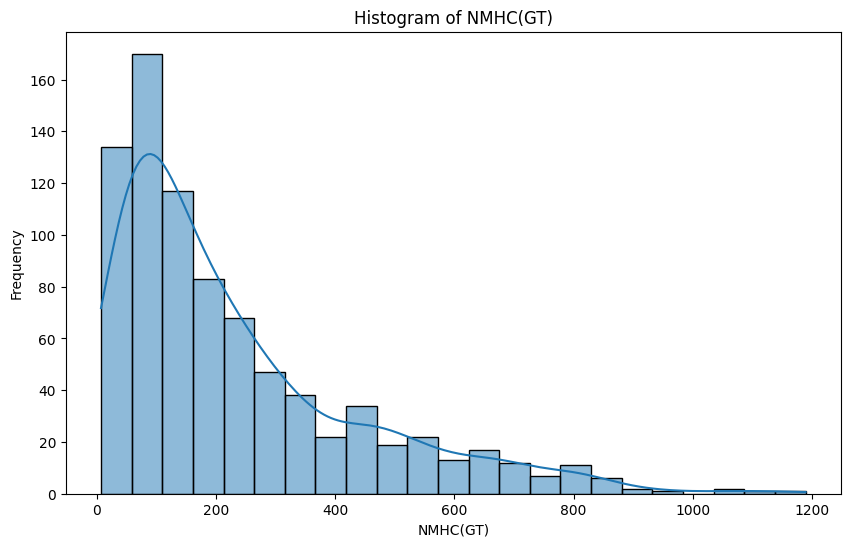

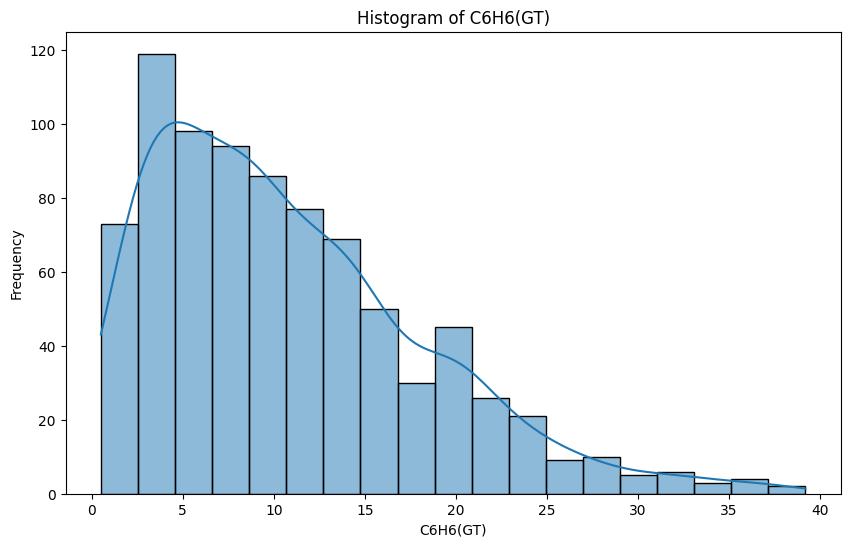

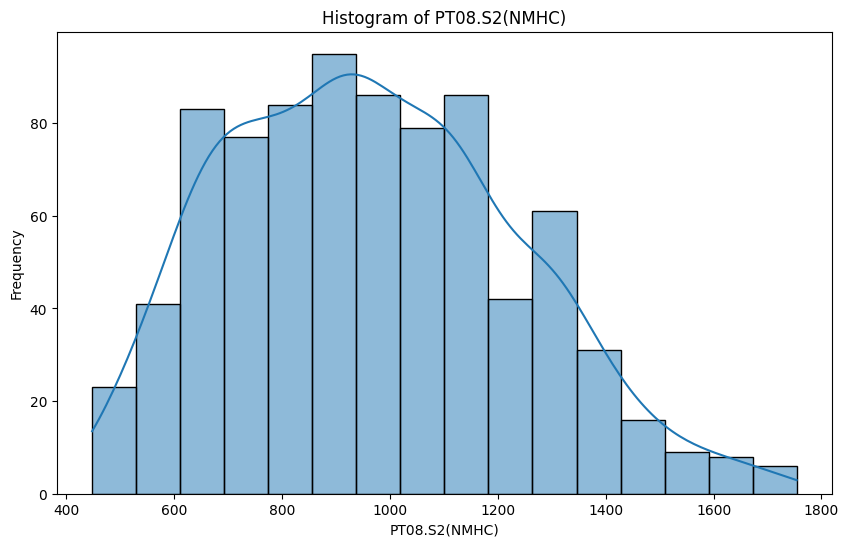

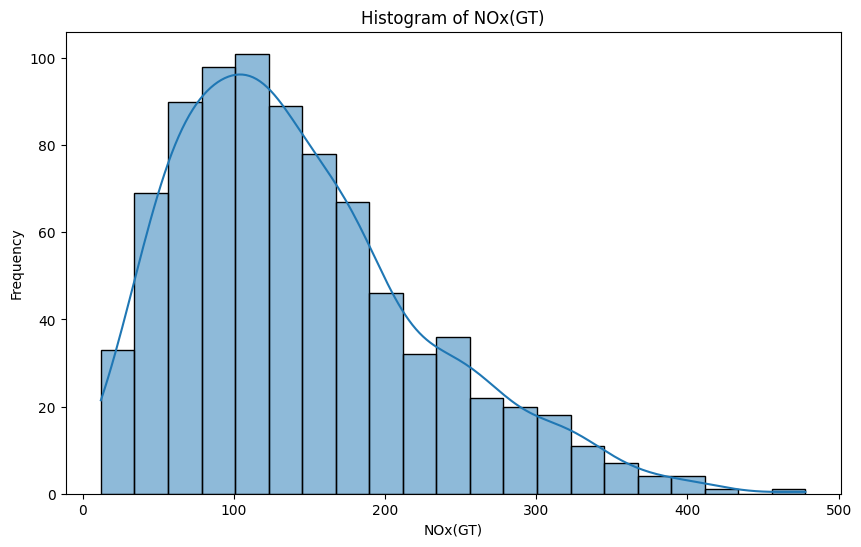

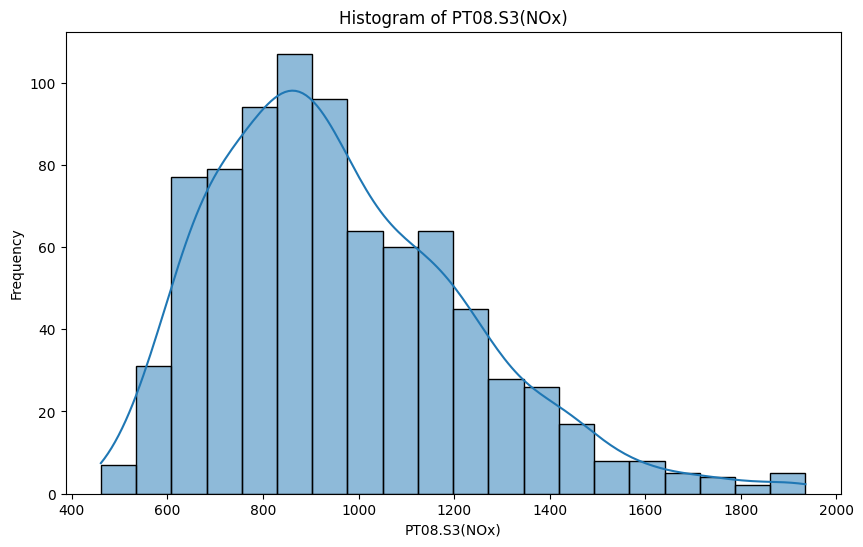

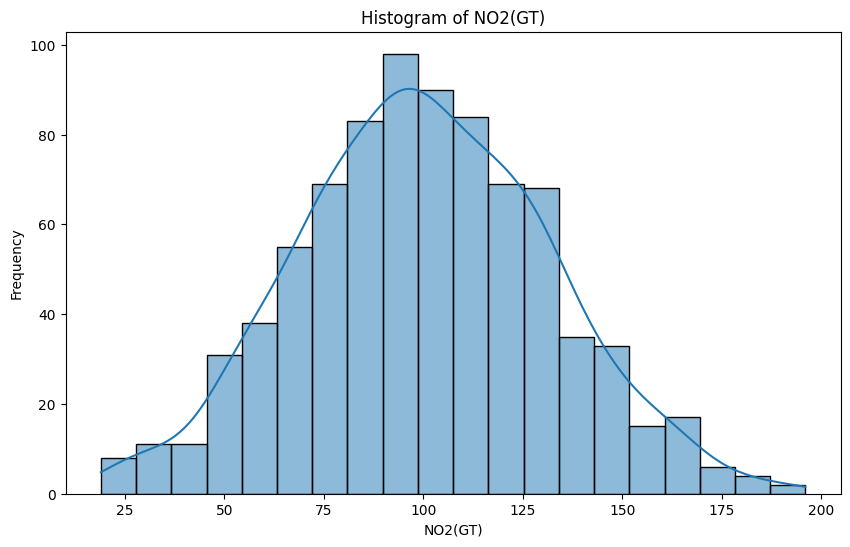

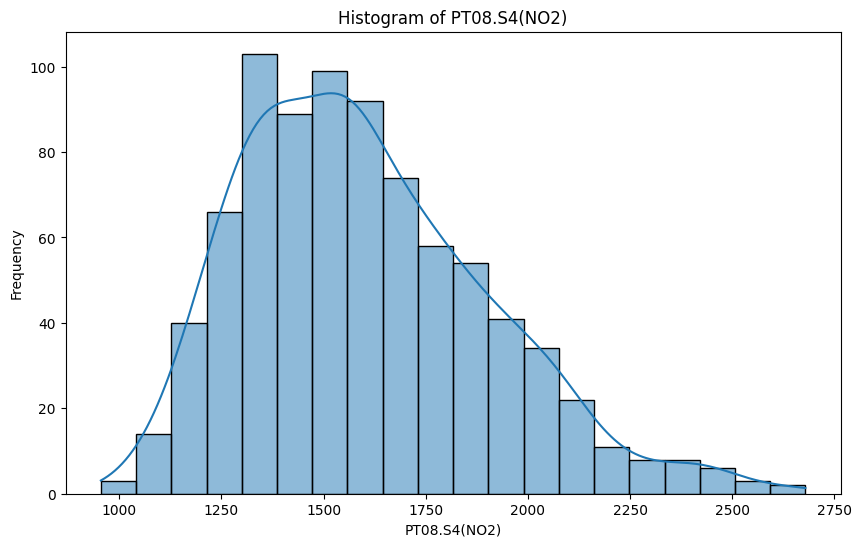

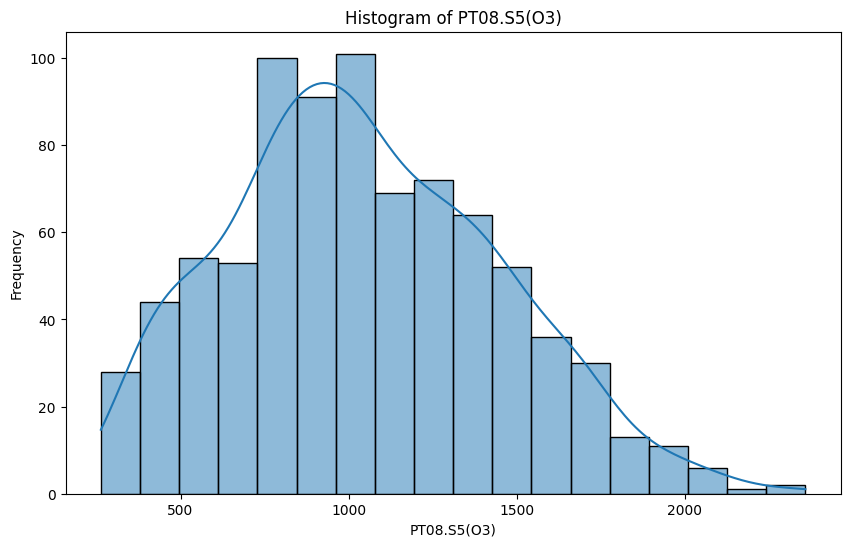

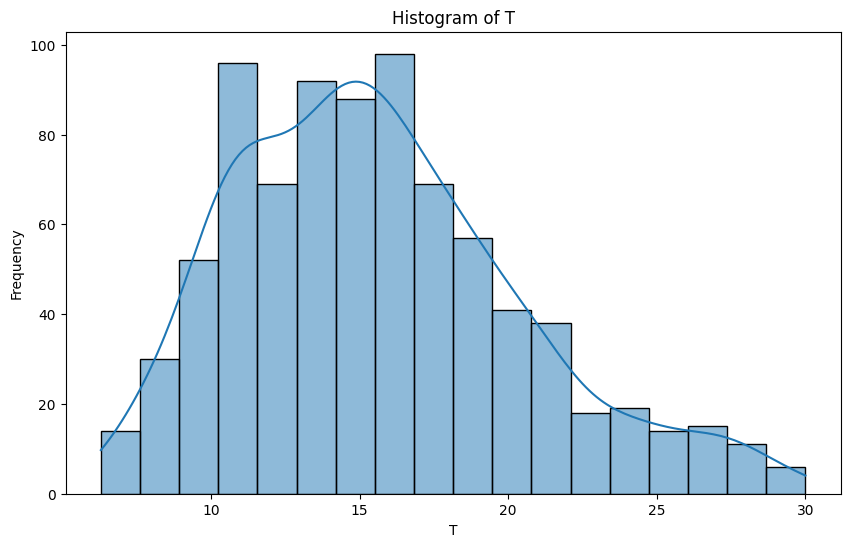

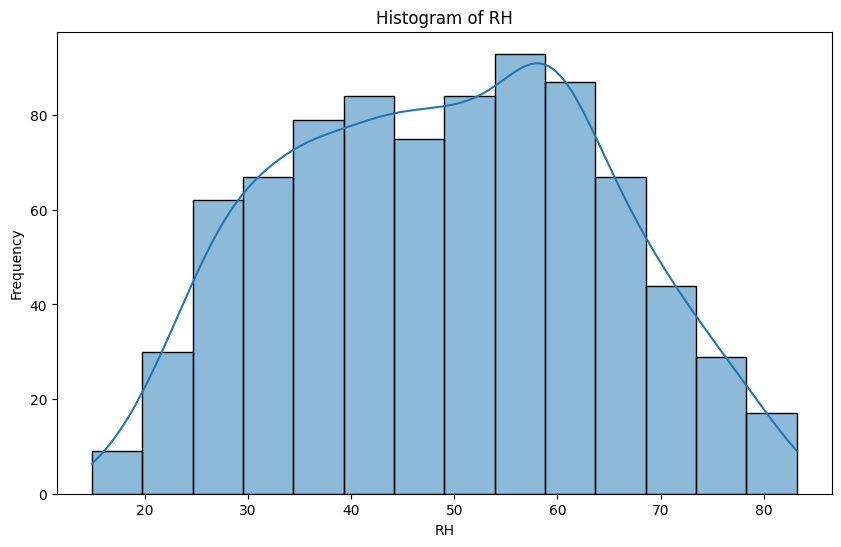

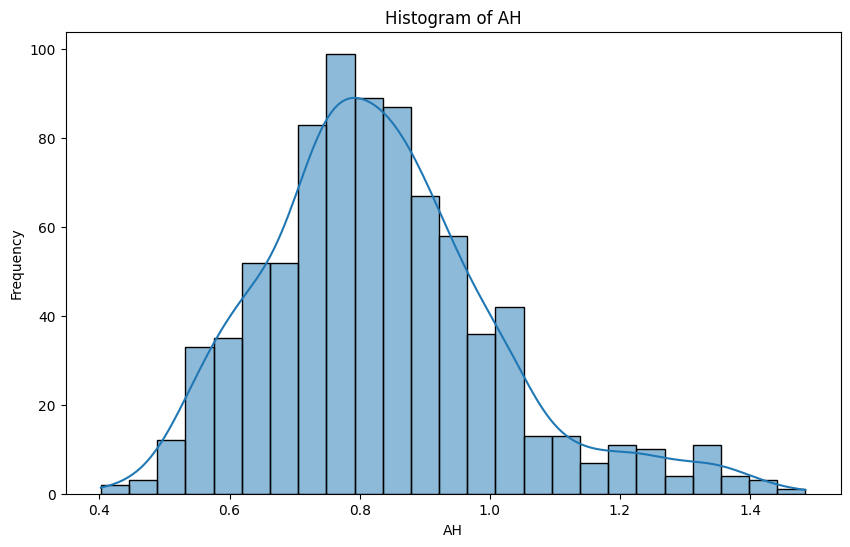

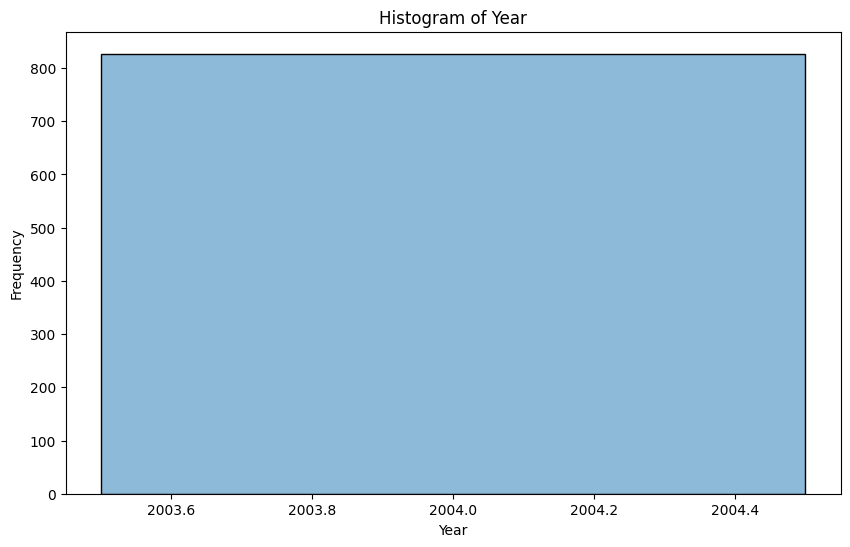

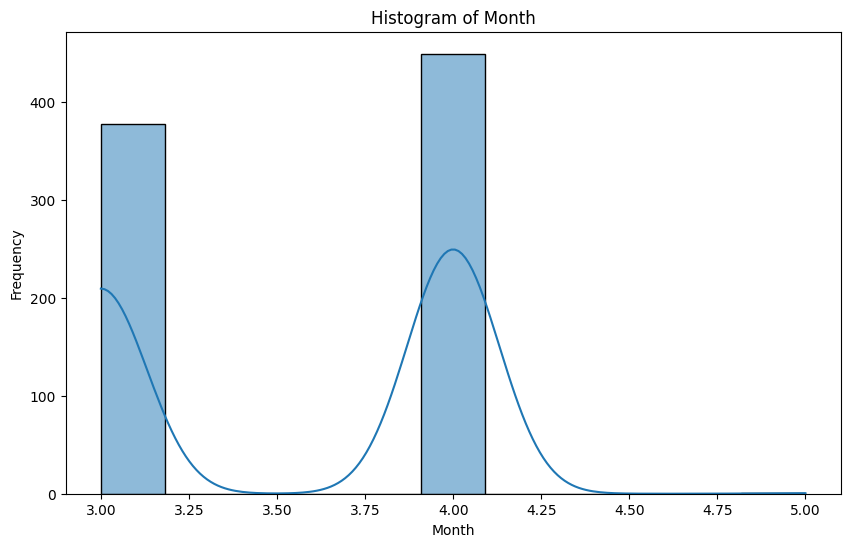

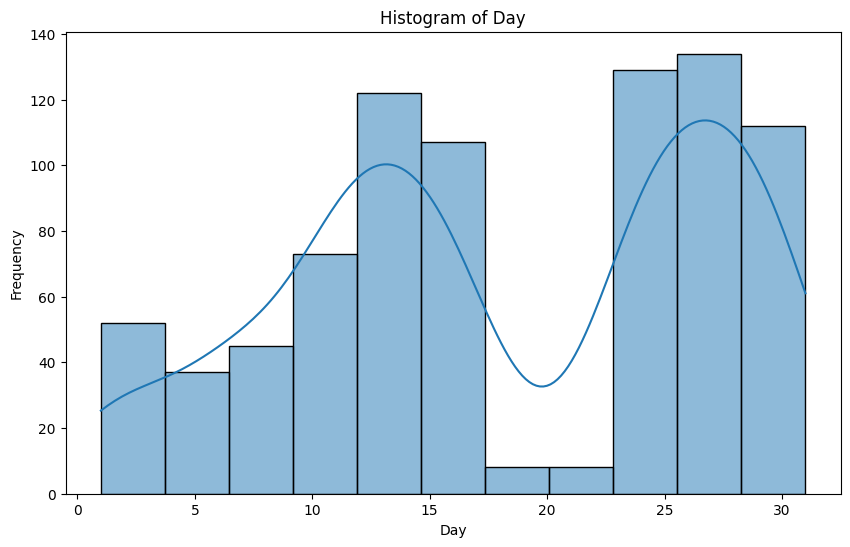

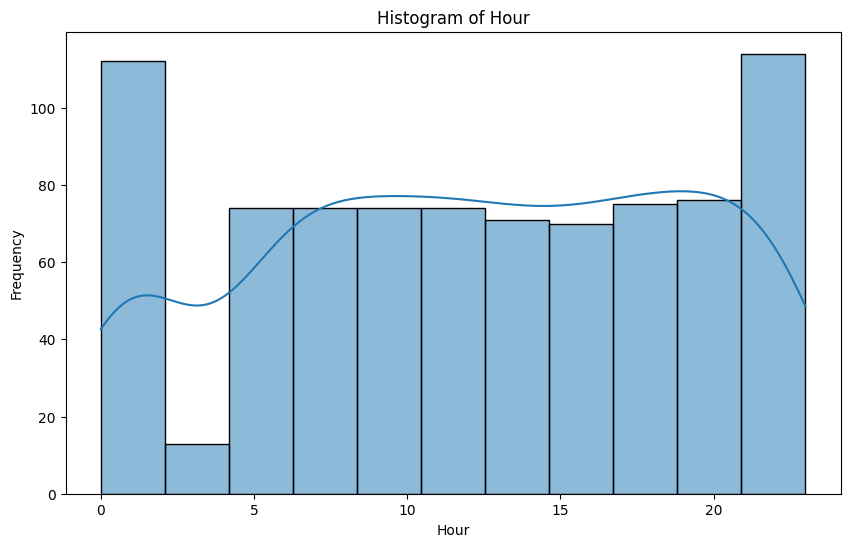

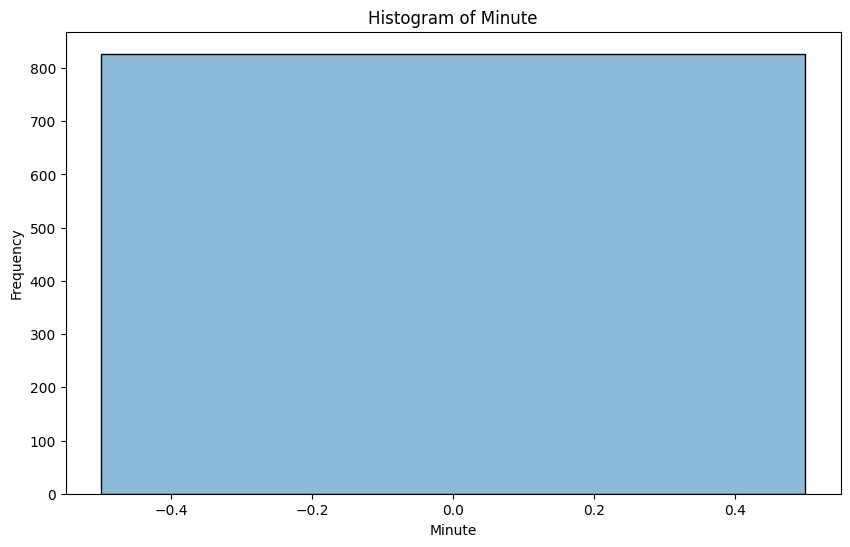

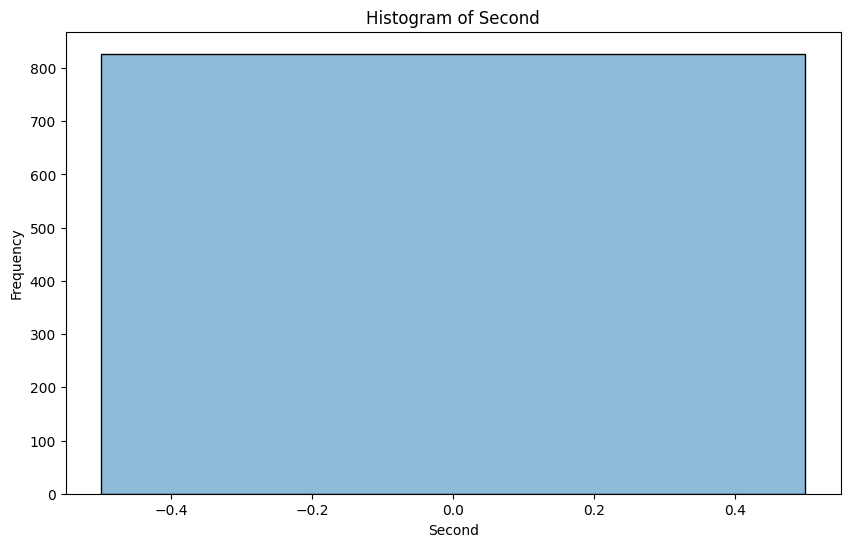


Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 0 to 1230
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         827 non-null    float32
 1   PT08.S1(CO)    827 non-null    float64
 2   NMHC(GT)       827 non-null    float64
 3   C6H6(GT)       827 non-null    float32
 4   PT08.S2(NMHC)  827 non-null    float64
 5   NOx(GT)        827 non-null    float64
 6   PT08.S3(NOx)   827 non-null    float64
 7   NO2(GT)        827 non-null    float64
 8   PT08.S4(NO2)   827 non-null    float64
 9   PT08.S5(O3)    827 non-null    float64
 10  T              827 non-null    float32
 11  RH             827 non-null    float32
 12  AH             827 non-null    float32
 13  Year           827 non-null    int32  
 14  Month          827 non-null    int32  
 15  Day            827 non-null    int32  
 16  Hour           827 non-null    int32  
 17  Minute         827 non-null

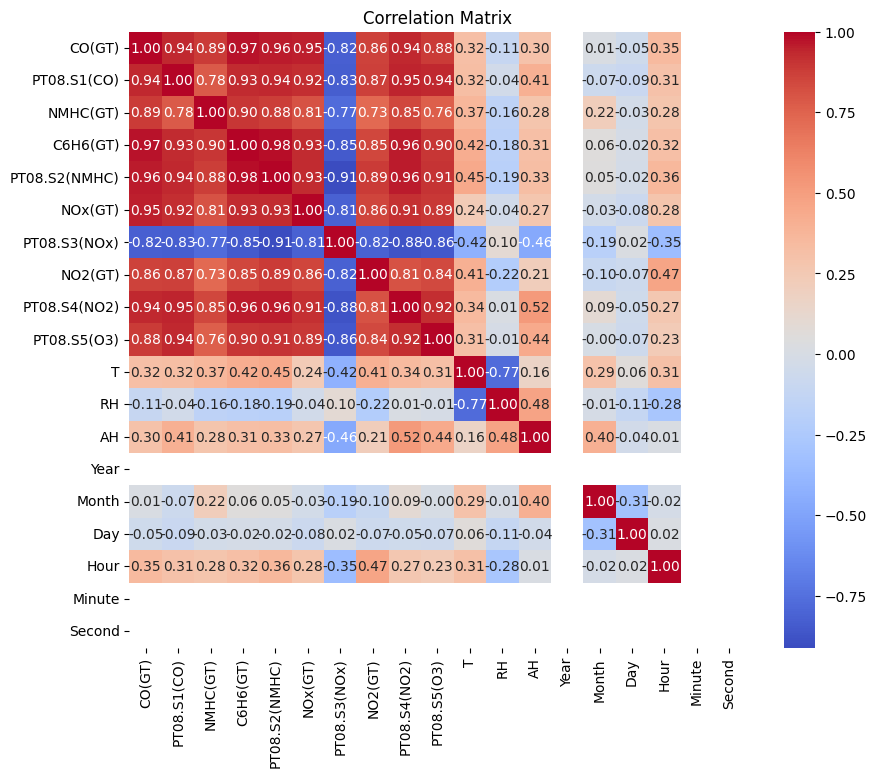


Preparing data for modeling...

Scaling features using Min-Max Scaling...

Scaled DataFrame head:
      CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  \
0  0.294872     0.471639  0.120981  0.294574       0.457887  0.330472   
1  0.217949     0.418803  0.088832  0.229974       0.388208  0.195279   
2  0.243590     0.504274  0.068528  0.219638       0.375957  0.255365   
3  0.243590     0.484071  0.061760  0.224806       0.382848  0.343348   
4  0.166667     0.403263  0.037225  0.155039       0.297090  0.255365   

   PT08.S3(NOx)   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)         T        RH  \
0      0.403664  0.531073      0.427494     0.479485  0.308017  0.497804   
1      0.483718  0.412429      0.350348     0.338263  0.295359  0.480234   
2      0.460651  0.536723      0.348028     0.386927  0.236287  0.572474   
3      0.428087  0.581921      0.364849     0.448473  0.198312  0.660322   
4      0.504749  0.548023      0.310325     0.404103  0.206751  0.654466   

    

In [51]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf

# Download latest version
path = kagglehub.dataset_download("fedesoriano/air-quality-data-set")

# Set the path to the file you'd like to load
file_path = f"{path}/AirQuality.csv"

# Load the CSV with the correct encoding
df = pd.read_csv(file_path, encoding='utf-8', delimiter=';')

print("First 5 records:\n", df.head())

print("\nEDA Summary:")
print(df.describe())

print("\nMissing values per column:\n", df.isnull().sum())

print("\nData types:\n", df.dtypes)

print("\nDeleting last two columns...")
df = df.iloc[:, :-2]

print("\nDataFrame shape after deletion:", df.shape)

print("\nColumn names:", df.columns.tolist())

print("\nDeleting rows with any missing values...")
df = df.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df.shape)

print("\nDeleting duplicate rows...")
df = df.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df.shape)

print("\nConverting 'CO(GT)', 'T', 'RH', 'C6H6(GT)' and 'AH' column to numeric...")
for col in ['CO(GT)', 'T', 'RH', 'C6H6(GT)', 'AH']:
    # Replace comma with dot for decimal conversion
    df[col] = df[col].str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce', downcast='float')
    
print("\nData types after conversion:\n", df.dtypes)

print("\nConverting 'Date' + 'Time' columns to 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'...")
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Minute'] = df['DateTime'].dt.minute
df['Second'] = df['DateTime'].dt.second
df = df.drop(columns=['Date', 'Time', 'DateTime'])

print("\nDataFrame shape after datetime conversion:", df.shape)

print("\nDeleting outliers. Values less than 0...")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df = df[df[col] >= 0]
    
print("\nPlotting hist plots for numeric columns...")
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

print("\nFinal cleaned DataFrame info:")
print(df.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df.head())

print("\nData cleaning completed.")

print("\nMatrix of correlations:\n")
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()


print("\nPreparing data for modeling...")

print("\nScaling features using Min-Max Scaling...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Separar las características de la variable objetivo
feature_cols = [col for col in numeric_cols if col != 'NO2(GT)']

# Escalar características
df[feature_cols] = scaler_X.fit_transform(df[feature_cols])

# Escalar variable objetivo
df[['NO2(GT)']] = scaler_y.fit_transform(df[['NO2(GT)']])

print("\nScaled DataFrame head:\n", df.head())



Splitting data into training and testing sets (70% train, 30% test)...
Entrenando Modelo 1 (1 característica)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0564 - val_loss: 0.0137
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0106 - val_loss: 0.0079
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 - val_loss: 0.0115
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.0068
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0091
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0094
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0080 - val_loss: 0.0071
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0068
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0076 - val_loss: 0.0066
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0065
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0068 - val_l

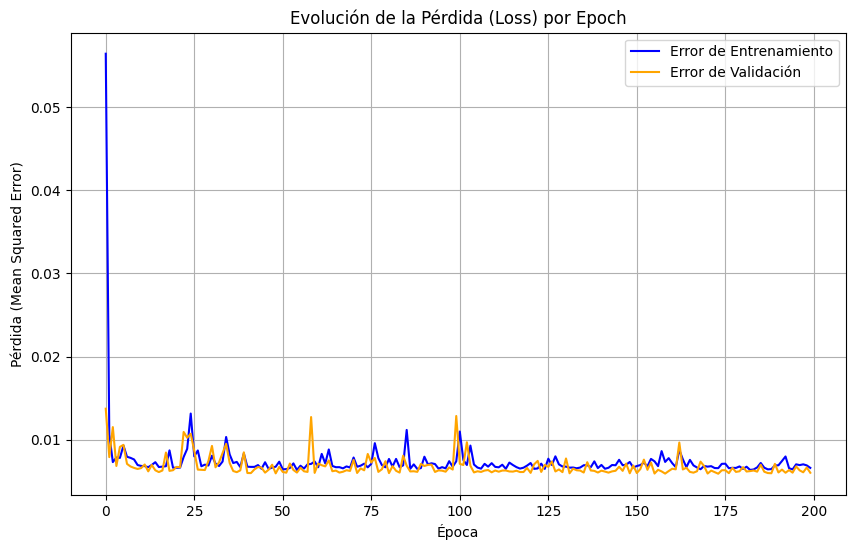

In [52]:
X = df[['PT08.S2(NMHC)']]
y = df['NO2(GT)']

print("\nSplitting data into training and testing sets (70% train, 30% test)...")
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Simple
model_1 = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(X.columns)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 1 (1 característica)...')
history_1 = model_1.fit(X_train_1, y_train_1, epochs=200, validation_data=(X_test_1, y_test_1))

# Evaluación
loss_1 = model_1.evaluate(X_test_1, y_test_1, verbose=0)
print(f'Pérdida Modelo 1 en Test: {loss_1}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_1.history['val_loss'], color='orange', label='Error de Validación')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()


Splitting data into training and testing sets (70% train, 30% test)...
Entrenando Modelo 2 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0385 - val_loss: 0.0104
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0057
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 0.0052
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0055
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 0.0072
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - val_loss: 0.0078
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - val_loss: 0.0050
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - val_loss: 0.0039
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - val_l

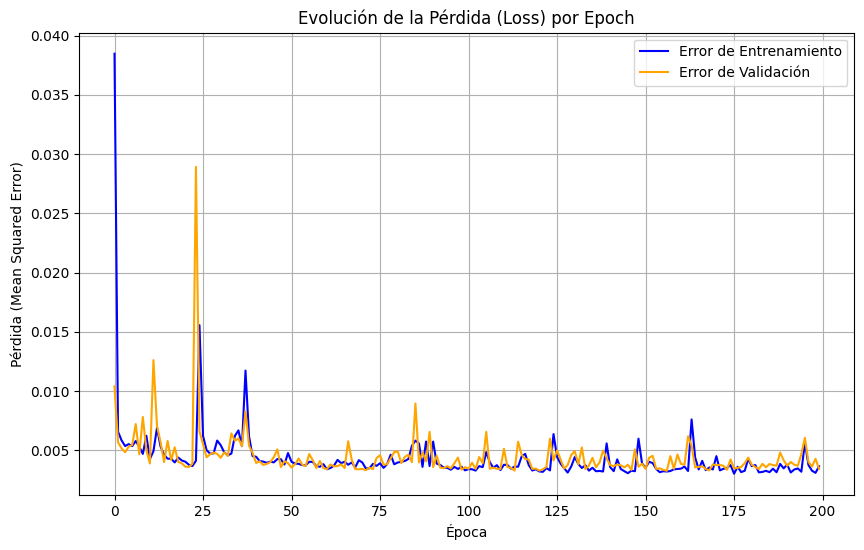

In [53]:
X = df[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']]
y = df['NO2(GT)']

print("\nSplitting data into training and testing sets (70% train, 30% test)...")
X_train_M, X_test_M, y_train_M, y_test_M = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Multivariable
model_M = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(X.columns)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 2 (Múltiples características)...')
history_M = model_M.fit(X_train_M, y_train_M, epochs=200, validation_data=(X_test_M, y_test_M))

# Evaluación
loss_M = model_M.evaluate(X_test_M, y_test_M, verbose=0)
print(f'Pérdida Modelo 2 en Test: {loss_M}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M.history['val_loss'], color='orange', label='Error de Validación')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()


Splitting data into training and testing sets (70% train, 30% test)...
Entrenando Modelo 3 (1 característica)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1489 - val_loss: 0.0783
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0691 - val_loss: 0.0648
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0656 - val_loss: 0.0877
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0758 - val_loss: 0.0846
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0900 - val_loss: 0.0702
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0687 - val_loss: 0.0708
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0649 - val_loss: 0.0634
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0656 - val_loss: 0.0648
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0654 - val_loss: 0.0746
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0696 - val_loss: 0.0637
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0672 - val_loss: 0.0677
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0673 - val_l

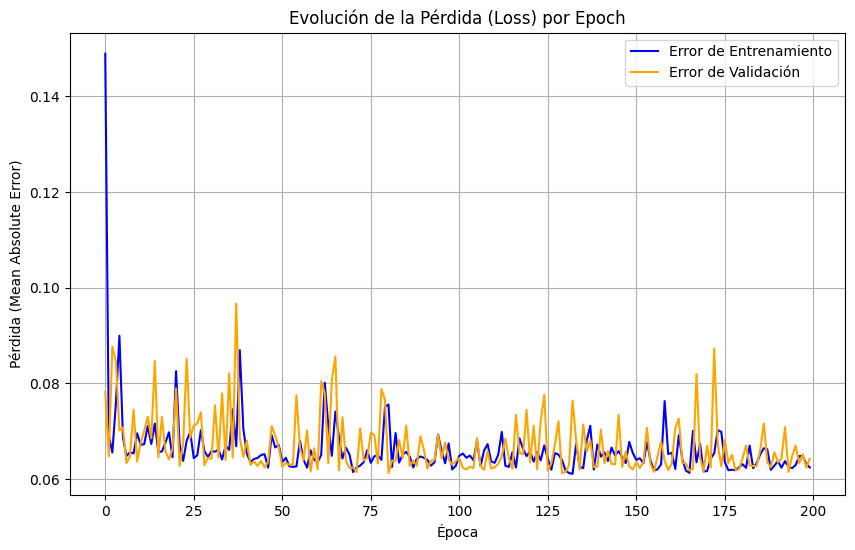

In [54]:
X = df[['PT08.S2(NMHC)']]
y = df['NO2(GT)']

print("\nSplitting data into training and testing sets (70% train, 30% test)...")
X_train_1_a, X_test_1_a, y_train_1_a, y_test_1_a = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Simple
model_1_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(X.columns)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 3 (1 característica)...')
history_1_a = model_1_a.fit(X_train_1_a, y_train_1_a, epochs=200, validation_data=(X_test_1_a, y_test_1_a))

# Evaluación
loss_1_a = model_1_a.evaluate(X_test_1_a, y_test_1_a, verbose=0)
print(f'Pérdida Modelo 3 en Test: {loss_1_a}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_1_a.history['val_loss'], color='orange', label='Error de Validación')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Absolute Error)')
plt.legend()
plt.grid(True)
plt.show()


Splitting data into training and testing sets (70% train, 30% test)...
Entrenando Modelo 4 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1178 - val_loss: 0.0649
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0631 - val_loss: 0.0587
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0561 - val_loss: 0.0569
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0613 - val_loss: 0.0717
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0652 - val_loss: 0.0609
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0568 - val_loss: 0.0622
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0543 - val_loss: 0.0648
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0592 - val_loss: 0.0530
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0639 - val_loss: 0.0661
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0744 - val_loss: 0.0544
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0541 - val_loss: 0.0545
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0546 - val_l

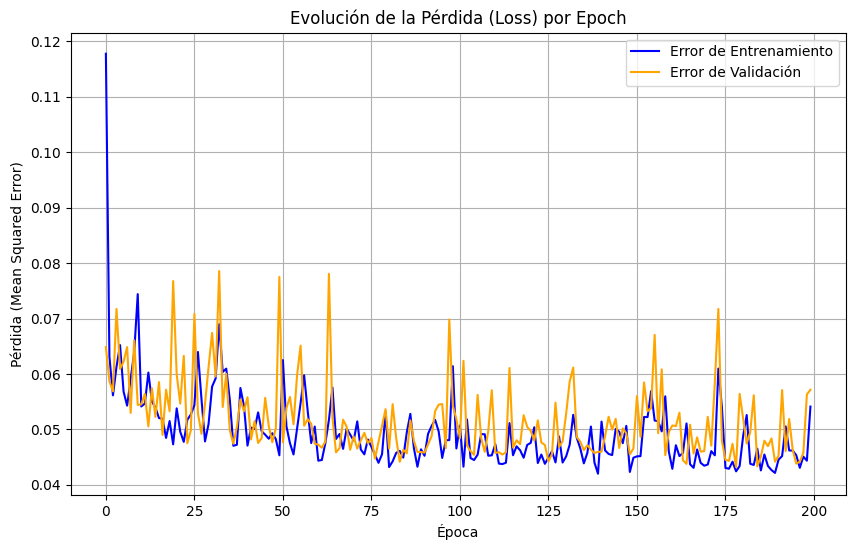

In [55]:
X = df[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']]
y = df['NO2(GT)']

print("\nSplitting data into training and testing sets (70% train, 30% test)...")
X_train_M_a, X_test_M_a, y_train_M_a, y_test_M_a = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Multivariable
model_M_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(X.columns)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 4 (Múltiples características)...')
history_M_a = model_M_a.fit(X_train_M_a, y_train_M_a, epochs=200, validation_data=(X_test_M_a, y_test_M_a))

# Evaluación
loss_M_a = model_M_a.evaluate(X_test_M_a, y_test_M_a, verbose=0)
print(f'Pérdida Modelo 4 en Test: {loss_M_a}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_a.history['val_loss'], color='orange', label='Error de Validación')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


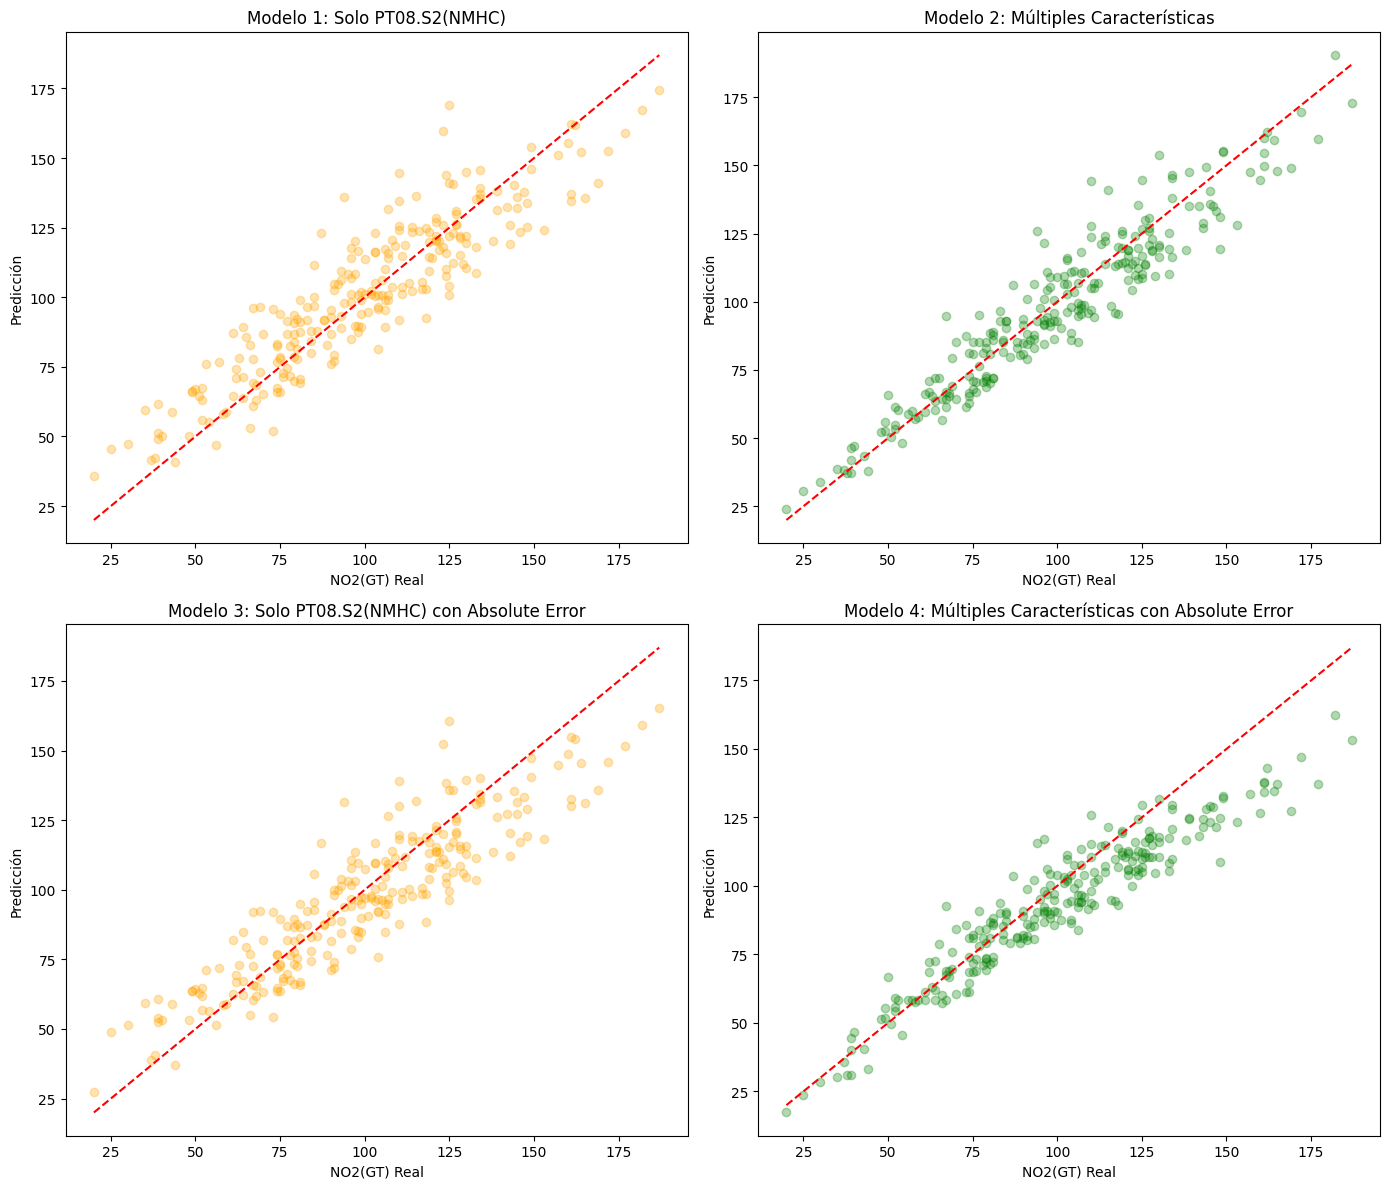


Comparativa de predicciones:
    Real  Pred_Simple  Pred_Multi  Pred_Simple_Absoluto  Pred_Multi_Absoluto
0   86.0    87.896721   79.710251             83.382553            79.231461
1   39.0    61.820702   46.546234             60.906643            44.659023
2   78.0    82.585327   81.088860             76.575882            80.858452
3  102.0   101.177986  106.431503             96.885315           101.225075
4  103.0   116.366959  106.340164            109.681091           102.598457
5  106.0    89.250465   85.378868             84.792343            84.041687
6  109.0   118.441521   95.964355            111.590904            91.746719
7  128.0   115.110756  122.999184            108.630699           118.249161
8   98.0   116.481148  109.248169            109.776588           104.322578
9   69.0    96.386627   79.204369             92.327049            75.725998

Diferencias entre predicciones y valores reales:
    Real  Diferencia_Simple_Cuadratico_Real  Diferencia_Multi_Cuadratico_

In [56]:
# Predicciones (desescaladas)
pred_1 = scaler_y.inverse_transform(model_1.predict(X_test_1).reshape(-1, 1))
pred_M = scaler_y.inverse_transform(model_M.predict(X_test_M).reshape(-1, 1))
pred_1_a = scaler_y.inverse_transform(model_1_a.predict(X_test_1_a).reshape(-1, 1))
pred_M_a = scaler_y.inverse_transform(model_M_a.predict(X_test_M_a).reshape(-1, 1))

# Desescalar los valores reales de y_test
y_test_1_real = scaler_y.inverse_transform(y_test_1.values.reshape(-1, 1))
y_test_M_real = scaler_y.inverse_transform(y_test_M.values.reshape(-1, 1))
y_test_1_a_real = scaler_y.inverse_transform(y_test_1_a.values.reshape(-1, 1))
y_test_M_a_real = scaler_y.inverse_transform(y_test_M_a.values.reshape(-1, 1))

# Visualización
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.scatter(y_test_1_real, pred_1, alpha=0.3, color='orange')
plt.plot([y_test_1_real.min(), y_test_1_real.max()], [y_test_1_real.min(), y_test_1_real.max()], 'r--')
plt.title('Modelo 1: Solo PT08.S2(NMHC)')
plt.xlabel('NO2(GT) Real')
plt.ylabel('Predicción')

plt.subplot(2, 2, 2)
plt.scatter(y_test_M_real, pred_M, alpha=0.3, color='green')
plt.plot([y_test_M_real.min(), y_test_M_real.max()], [y_test_M_real.min(), y_test_M_real.max()], 'r--')
plt.title('Modelo 2: Múltiples Características')
plt.xlabel('NO2(GT) Real')
plt.ylabel('Predicción')

plt.subplot(2, 2, 3)
plt.scatter(y_test_1_a_real, pred_1_a, alpha=0.3, color='orange')
plt.plot([y_test_1_a_real.min(), y_test_1_a_real.max()], [y_test_1_a_real.min(), y_test_1_a_real.max()], 'r--')
plt.title('Modelo 3: Solo PT08.S2(NMHC) con Absolute Error')
plt.xlabel('NO2(GT) Real')
plt.ylabel('Predicción')

plt.subplot(2, 2, 4)
plt.scatter(y_test_M_a_real, pred_M_a, alpha=0.3, color='green')
plt.plot([y_test_M_a_real.min(), y_test_M_a_real.max()], [y_test_M_a_real.min(), y_test_M_a_real.max()], 'r--')
plt.title('Modelo 4: Múltiples Características con Absolute Error')
plt.xlabel('NO2(GT) Real')
plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

# Tabla comparativa de los primeros 10 registros
comparativa = pd.DataFrame({
    'Real': y_test_1_real.flatten()[:10],
    'Pred_Simple': pred_1.flatten()[:10],
    'Pred_Multi': pred_M.flatten()[:10],
    'Pred_Simple_Absoluto': pred_1_a.flatten()[:10],
    'Pred_Multi_Absoluto': pred_M_a.flatten()[:10]
})

diferencias = pd.DataFrame({
    'Real': y_test_1_real.flatten()[:10],
    'Diferencia_Simple_Cuadratico_Real': (pred_1.flatten()[:10] - y_test_1_real.flatten()[:10]),
    'Diferencia_Multi_Cuadratico_Real': (pred_M.flatten()[:10] - y_test_M_real.flatten()[:10]),
    'Diferencia_Simple_Absoluto_Real': (pred_1_a.flatten()[:10] - y_test_1_a_real.flatten()[:10]),
    'Diferencia_Multi_Absoluto_Real': (pred_M_a.flatten()[:10] - y_test_M_a_real.flatten()[:10]),
    'Ganador_Cuadratico': np.where(
        abs(pred_1.flatten()[:10] - y_test_1_real.flatten()[:10]) <
        abs(pred_M.flatten()[:10] - y_test_M_real.flatten()[:10]),
        'Simple',
        'Multi'
    ),
    'Ganador_Absoluto': np.where(
        abs(pred_1_a.flatten()[:10] - y_test_1_a_real.flatten()[:10]) <
        abs(pred_M_a.flatten()[:10] - y_test_M_a_real.flatten()[:10]),
        'Simple',
        'Multi'
    )
})

cols_error = [
    'Diferencia_Simple_Cuadratico_Real', 
    'Diferencia_Multi_Cuadratico_Real', 
    'Diferencia_Simple_Absoluto_Real', 
    'Diferencia_Multi_Absoluto_Real'
]

diferencias['Ganador_Global'] = diferencias[cols_error].abs().idxmin(axis=1).replace({
    'Diferencia_Simple_Cuadratico_Real': 'Simple Cuadrático',
    'Diferencia_Multi_Cuadratico_Real': 'Multi Cuadrático',
    'Diferencia_Simple_Absoluto_Real': 'Simple Absoluto',
    'Diferencia_Multi_Absoluto_Real': 'Multi Absoluto'
})

diferencias = diferencias.drop(columns=['Ganador_Cuadratico', 'Ganador_Absoluto'])

print('\nComparativa de predicciones:')
print(comparativa)
print('\nDiferencias entre predicciones y valores reales:')
print(diferencias)



Resumen de Ganadores Globales y Métricas de Error:
                         MAE         MSE       RMSE        R²  SMAPE (%)  \
Multi Cuadrático    8.305245  107.589653  10.372543  0.895360   8.558195   
Multi Absoluto     10.114131  167.701558  12.949964  0.836897  10.058273   
Simple Cuadrático  10.940313  188.836147  13.741767  0.816342  11.890965   
Simple Absoluto    11.378568  200.445468  14.157877  0.805051  12.254218   

                       SMSE  Número de Victorias  Porcentaje de Victoria  
Multi Cuadrático   0.010681                   70               28.112450  
Multi Absoluto     0.014313                   71               28.514056  
Simple Cuadrático  0.023958                   64               25.702811  
Simple Absoluto    0.023961                   44               17.670683  

El modelo con mejor R² es: Multi Cuadrático
R² del mejor modelo: 0.8954
SMAPE del mejor modelo: 8.56%


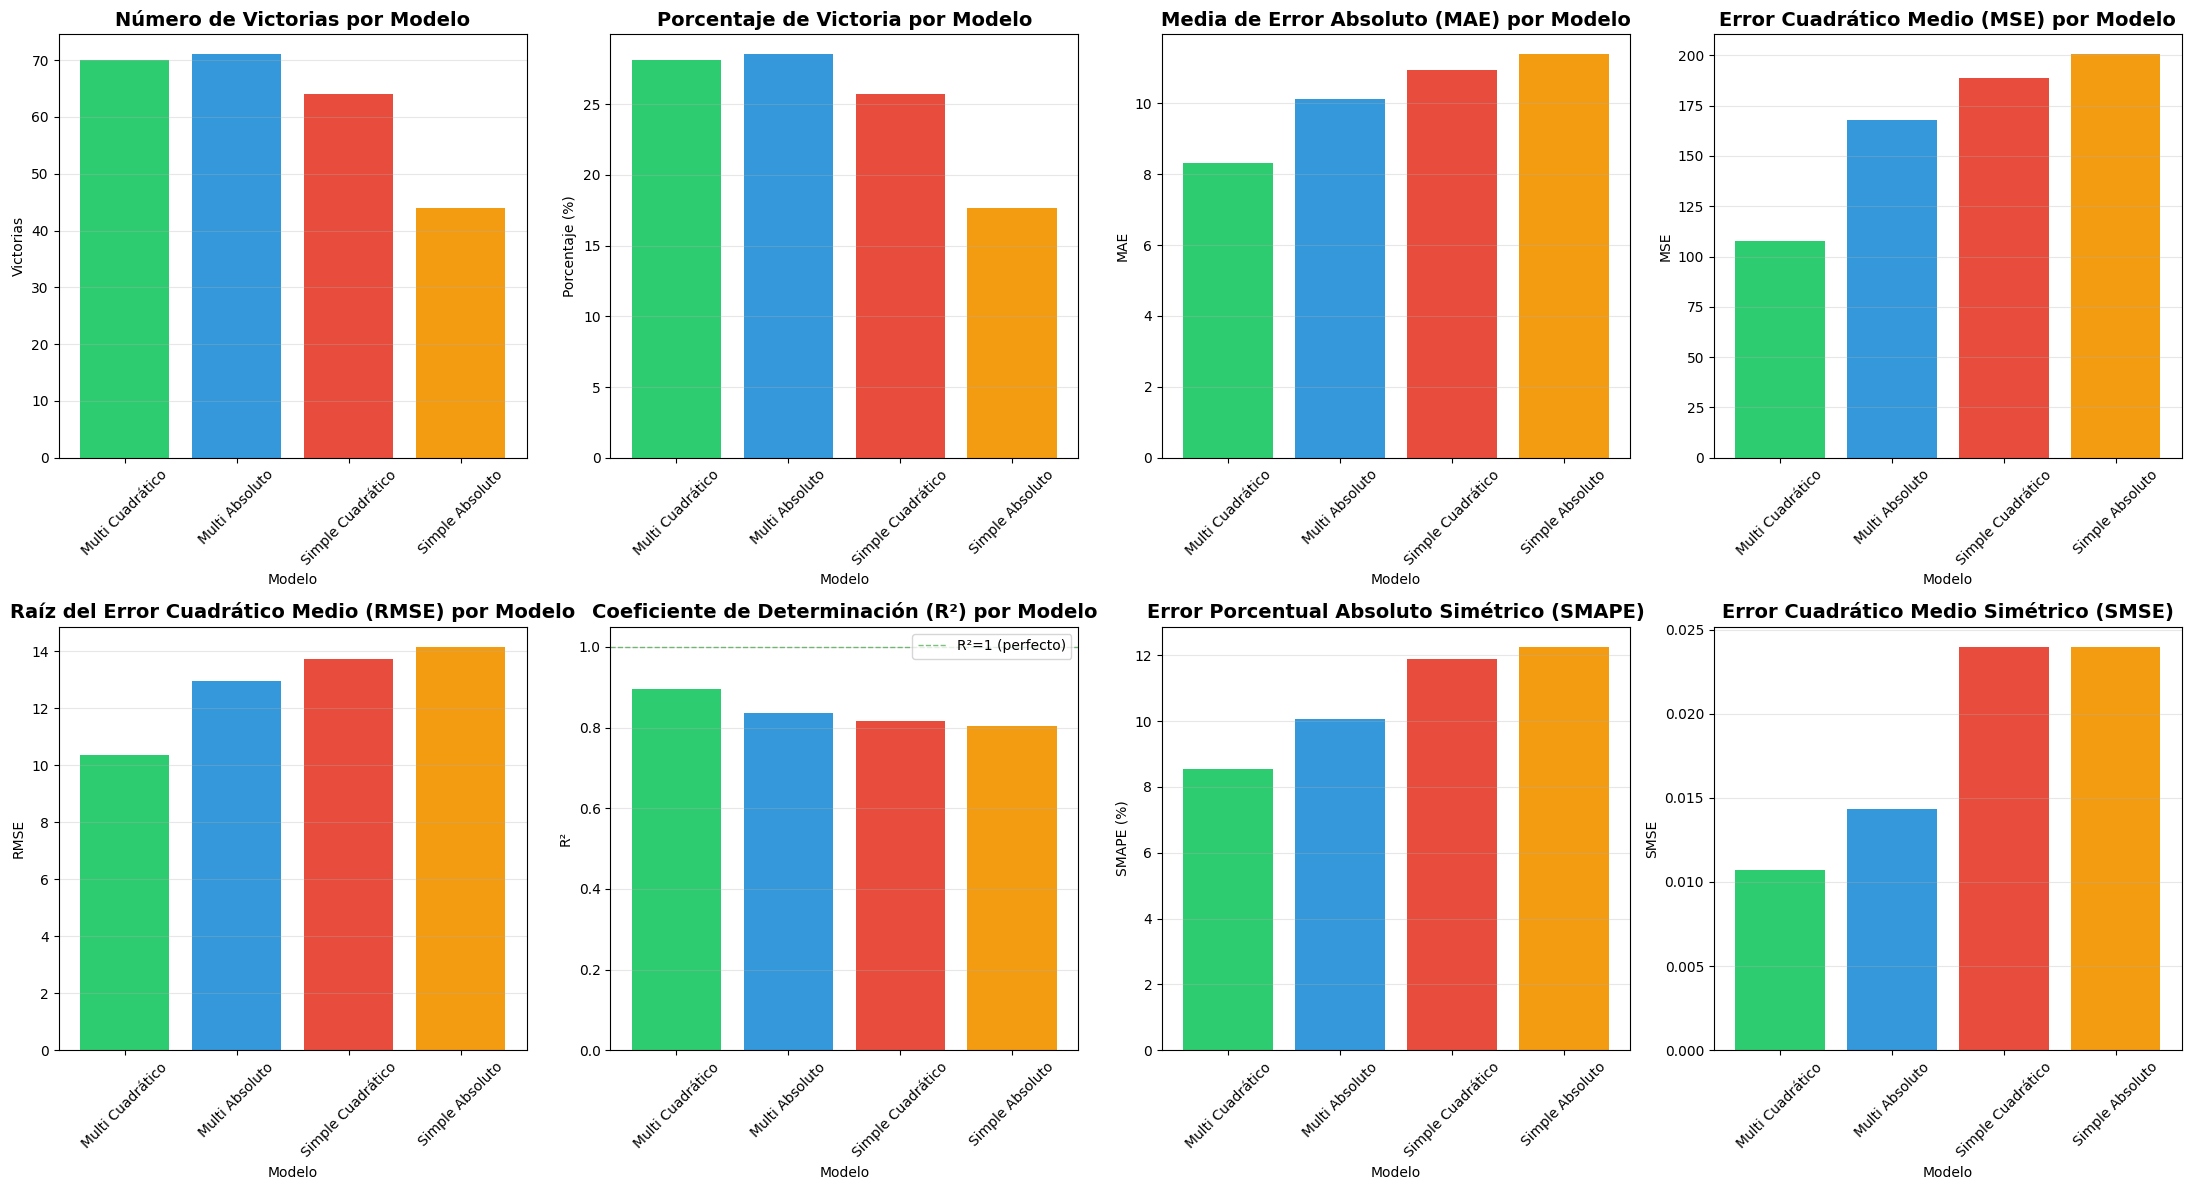

In [60]:
# Función para calcular SMAPE (Symmetric Mean Absolute Percentage Error)
def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

# Función para calcular SMSE (Symmetric Mean Squared Error)
def smse(y_true, y_pred):
    return np.mean(((y_pred - y_true) ** 2) / ((y_true ** 2 + y_pred ** 2) / 2))

errores_totales = pd.DataFrame({
    'Simple Cuadrático': np.abs(pred_1.flatten() - y_test_1_real.flatten()),
    'Multi Cuadrático': np.abs(pred_M.flatten() - y_test_M_real.flatten()),
    'Simple Absoluto': np.abs(pred_1_a.flatten() - y_test_1_a_real.flatten()),
    'Multi Absoluto': np.abs(pred_M_a.flatten() - y_test_M_a_real.flatten())
})

ganador_por_registro = errores_totales.idxmin(axis=1)

conteo_victorias = ganador_por_registro.value_counts()
porcentaje_victorias = ganador_por_registro.value_counts(normalize=True) * 100
media_errores = errores_totales.mean()

modelos_data = {
    'Simple Cuadrático': (y_test_1_real.flatten(), pred_1.flatten()),
    'Multi Cuadrático': (y_test_M_real.flatten(), pred_M.flatten()),
    'Simple Absoluto': (y_test_1_a_real.flatten(), pred_1_a.flatten()),
    'Multi Absoluto': (y_test_M_a_real.flatten(), pred_M_a.flatten())
}

metricas_dict = {}

for nombre, (real, pred) in modelos_data.items():
    mse_val = mean_squared_error(real, pred)
    metricas_dict[nombre] = {
        'MAE': mean_absolute_error(real, pred),
        'MSE': mse_val,
        'RMSE': np.sqrt(mse_val),
        'R²': r2_score(real, pred),
        'SMAPE (%)': smape(real, pred),
        'SMSE': smse(real, pred)
    }

resumen_rendimiento = pd.DataFrame(metricas_dict).T

resumen_rendimiento['Número de Victorias'] = conteo_victorias
resumen_rendimiento['Porcentaje de Victoria'] = porcentaje_victorias

resumen_rendimiento = resumen_rendimiento.sort_values(by='R²', ascending=False)

print('\nResumen de Ganadores Globales y Métricas de Error:')
print(resumen_rendimiento)

modelo_mejor_general = resumen_rendimiento.index[0]
print(f'\nEl modelo con mejor R² es: {modelo_mejor_general}')
print(f'R² del mejor modelo: {resumen_rendimiento.loc[modelo_mejor_general, "R²"]:.4f}')
print(f'SMAPE del mejor modelo: {resumen_rendimiento.loc[modelo_mejor_general, "SMAPE (%)"]:.2f}%')

# Gráficos de barras del resumen
fig, axes = plt.subplots(2, 4, figsize=(22, 12))

# Gráfico 1: Número de Victorias
axes[0, 0].bar(resumen_rendimiento.index, resumen_rendimiento['Número de Victorias'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 0].set_title('Número de Victorias por Modelo', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Modelo')
axes[0, 0].set_ylabel('Victorias')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Porcentaje de Victoria
axes[0, 1].bar(resumen_rendimiento.index, resumen_rendimiento['Porcentaje de Victoria'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 1].set_title('Porcentaje de Victoria por Modelo', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Modelo')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: MAE
axes[0, 2].bar(resumen_rendimiento.index, resumen_rendimiento['MAE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 2].set_title('Media de Error Absoluto (MAE) por Modelo', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Modelo')
axes[0, 2].set_ylabel('MAE')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)

# Gráfico 4: MSE
axes[0, 3].bar(resumen_rendimiento.index, resumen_rendimiento['MSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 3].set_title('Error Cuadrático Medio (MSE) por Modelo', fontsize=14, fontweight='bold')
axes[0, 3].set_xlabel('Modelo')
axes[0, 3].set_ylabel('MSE')
axes[0, 3].tick_params(axis='x', rotation=45)
axes[0, 3].grid(axis='y', alpha=0.3)

# Gráfico 5: RMSE
axes[1, 0].bar(resumen_rendimiento.index, resumen_rendimiento['RMSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 0].set_title('Raíz del Error Cuadrático Medio (RMSE) por Modelo', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Modelo')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 6: R²
axes[1, 1].bar(resumen_rendimiento.index, resumen_rendimiento['R²'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 1].set_title('Coeficiente de Determinación (R²) por Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Modelo')
axes[1, 1].set_ylabel('R²')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(y=1.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='R²=1 (perfecto)')
axes[1, 1].legend()

# Gráfico 7: SMAPE
axes[1, 2].bar(resumen_rendimiento.index, resumen_rendimiento['SMAPE (%)'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 2].set_title('Error Porcentual Absoluto Simétrico (SMAPE)', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Modelo')
axes[1, 2].set_ylabel('SMAPE (%)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

# Gráfico 8: SMSE
axes[1, 3].bar(resumen_rendimiento.index, resumen_rendimiento['SMSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 3].set_title('Error Cuadrático Medio Simétrico (SMSE)', fontsize=14, fontweight='bold')
axes[1, 3].set_xlabel('Modelo')
axes[1, 3].set_ylabel('SMSE')
axes[1, 3].tick_params(axis='x', rotation=45)
axes[1, 3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


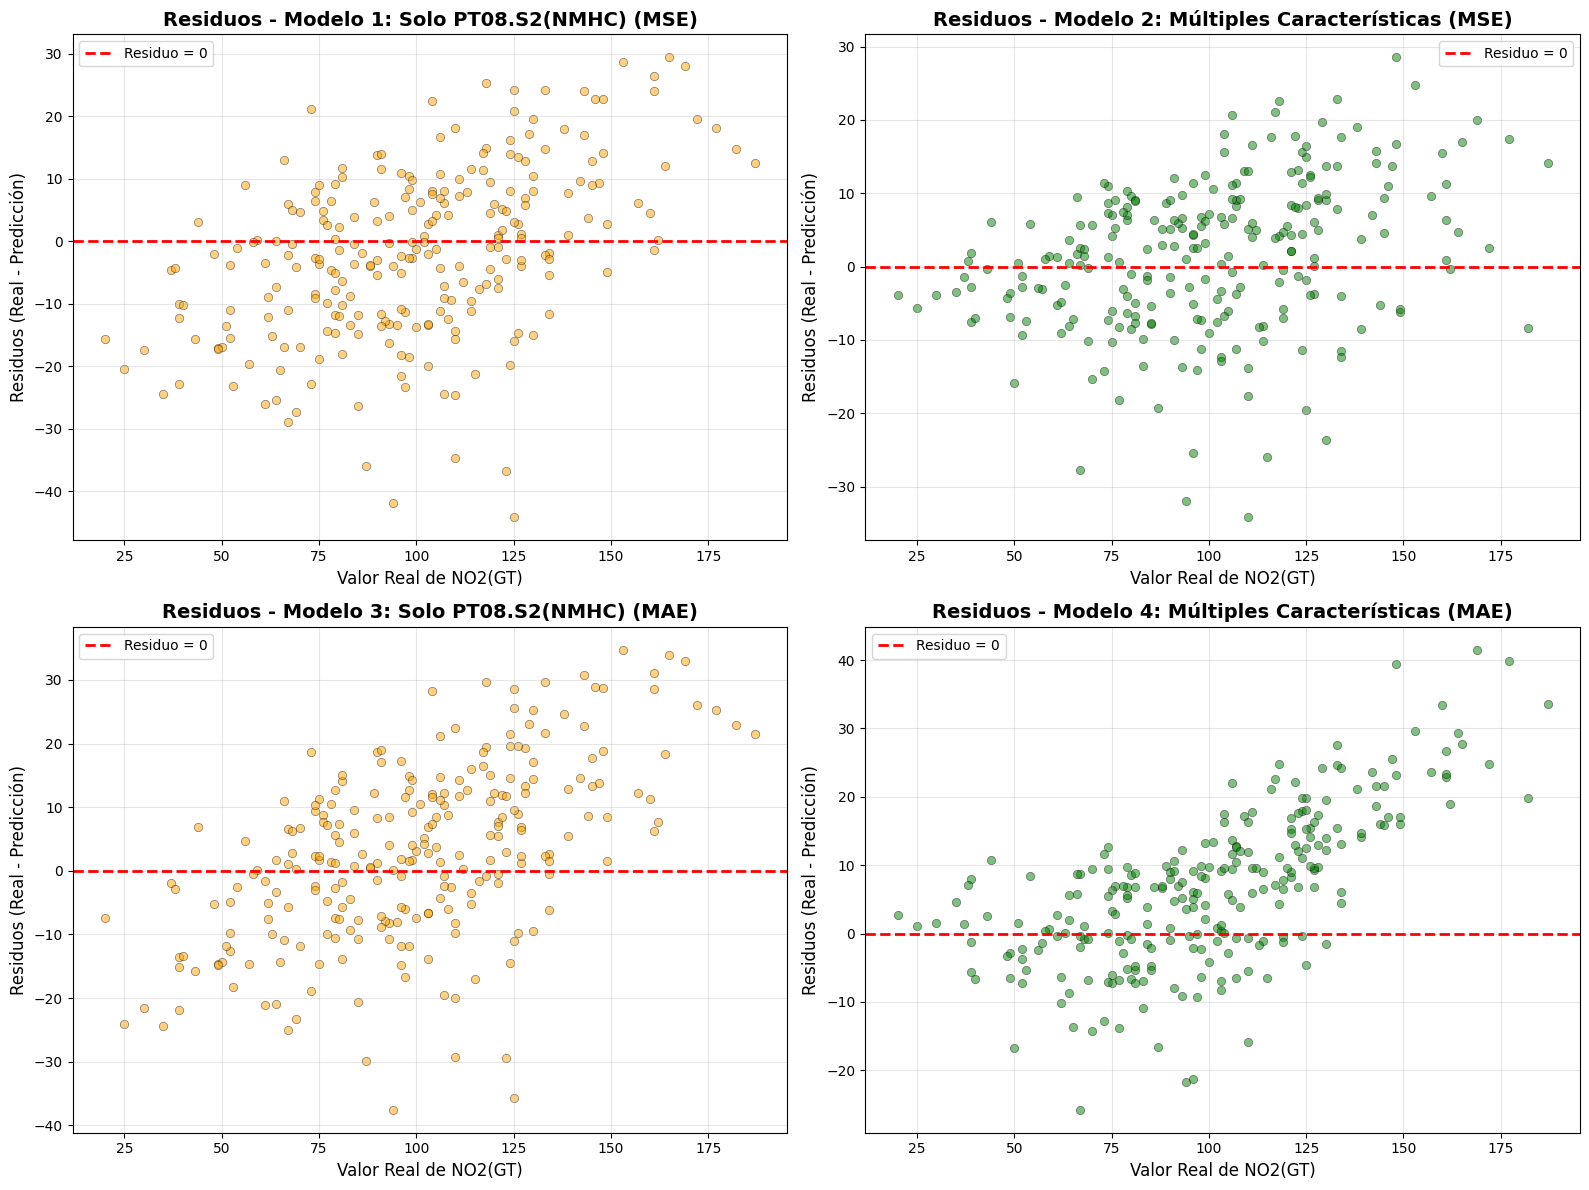


Estadísticas de Residuos por Modelo:

                Modelo 1 (Simple MSE)  Modelo 2 (Multi MSE)  \
Media                       -1.875198              1.599083   
Desv. Estándar              13.613221             10.248541   
Mínimo                     -44.193329            -34.176895   
Máximo                      29.424225             28.526779   

                Modelo 3 (Simple MAE)  Modelo 4 (Multi MAE)  
Media                        2.747364              6.560015  
Desv. Estándar              13.888753             11.165472  
Mínimo                     -37.548508            -25.767006  
Máximo                      34.724724             41.504204  


Nota: Los residuos ideales deberían:
  - Tener media cercana a 0 (sin sesgo)
  - Tener distribución aleatoria alrededor de 0
  - No mostrar patrones sistemáticos


In [61]:
# Calcular residuos para cada modelo
residuos_1 = y_test_1_real.flatten() - pred_1.flatten()
residuos_M = y_test_M_real.flatten() - pred_M.flatten()
residuos_1_a = y_test_1_a_real.flatten() - pred_1_a.flatten()
residuos_M_a = y_test_M_a_real.flatten() - pred_M_a.flatten()

# Crear gráficas de residuos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Residuos Modelo 1
axes[0, 0].scatter(y_test_1_real.flatten(), residuos_1, alpha=0.5, color='orange', edgecolors='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
axes[0, 0].set_title('Residuos - Modelo 1: Solo PT08.S2(NMHC) (MSE)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Valor Real de NO2(GT)', fontsize=12)
axes[0, 0].set_ylabel('Residuos (Real - Predicción)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Gráfico 2: Residuos Modelo 2
axes[0, 1].scatter(y_test_M_real.flatten(), residuos_M, alpha=0.5, color='green', edgecolors='black', linewidth=0.5)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
axes[0, 1].set_title('Residuos - Modelo 2: Múltiples Características (MSE)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Valor Real de NO2(GT)', fontsize=12)
axes[0, 1].set_ylabel('Residuos (Real - Predicción)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Gráfico 3: Residuos Modelo 3
axes[1, 0].scatter(y_test_1_a_real.flatten(), residuos_1_a, alpha=0.5, color='orange', edgecolors='black', linewidth=0.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
axes[1, 0].set_title('Residuos - Modelo 3: Solo PT08.S2(NMHC) (MAE)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Valor Real de NO2(GT)', fontsize=12)
axes[1, 0].set_ylabel('Residuos (Real - Predicción)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Gráfico 4: Residuos Modelo 4
axes[1, 1].scatter(y_test_M_a_real.flatten(), residuos_M_a, alpha=0.5, color='green', edgecolors='black', linewidth=0.5)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
axes[1, 1].set_title('Residuos - Modelo 4: Múltiples Características (MAE)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Valor Real de NO2(GT)', fontsize=12)
axes[1, 1].set_ylabel('Residuos (Real - Predicción)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Estadísticas de los residuos
print('\nEstadísticas de Residuos por Modelo:\n')
print('=' * 80)

estadisticas_residuos = pd.DataFrame({
    'Modelo 1 (Simple MSE)': [residuos_1.mean(), residuos_1.std(), residuos_1.min(), residuos_1.max()],
    'Modelo 2 (Multi MSE)': [residuos_M.mean(), residuos_M.std(), residuos_M.min(), residuos_M.max()],
    'Modelo 3 (Simple MAE)': [residuos_1_a.mean(), residuos_1_a.std(), residuos_1_a.min(), residuos_1_a.max()],
    'Modelo 4 (Multi MAE)': [residuos_M_a.mean(), residuos_M_a.std(), residuos_M_a.min(), residuos_M_a.max()]
}, index=['Media', 'Desv. Estándar', 'Mínimo', 'Máximo'])

print(estadisticas_residuos)
print('\n' + '=' * 80)
print('\nNota: Los residuos ideales deberían:')
print('  - Tener media cercana a 0 (sin sesgo)')
print('  - Tener distribución aleatoria alrededor de 0')
print('  - No mostrar patrones sistemáticos')
